# Assignment 2: Data Wrangling and Visualisation

**Course:** Big Data Analytics  
**Topic:** Data Wrangling and Visualisation  
**Dataset:** Predict Students' Dropout and Academic Success

### Objective
Perform practical **data wrangling** operations on a loaded dataset and create appropriate visualisations such as:

- Histogram
- Line chart
- Scatter plot
- Box plot
- Pie chart
- Bar/count chart
- Multi-plot grid
- Correlation heatmap

The notebook uses the student academic success dataset already used in the previous work. The original dataset is kept unchanged; wrangling examples are performed on copies so that later analysis remains possible.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The dataset is semicolon-separated, so `sep=';'` is required. The CSV is expected to be in the same folder as this notebook.

In [2]:
DATA_PATH = Path("predict students dropout and academic success.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Keep the CSV file in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Initial Dataset Inspection

In [3]:
# First five rows
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
# Last five rows
df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.0,1,1,1,5,4,122.2,0,0,0,1,1,0,19,0,0,6,7,5,13.600000,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,9,9,119.0,1,0,1,0,0,0,18,1,0,6,6,6,12.000000,0,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,9,9,149.5,1,0,0,1,0,1,30,0,0,7,8,7,14.912500,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,7,4,153.8,1,0,0,1,0,1,20,0,0,5,5,5,13.800000,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,5,9,152.0,1,0,0,1,0,0,22,1,0,6,8,6,11.666667,0,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [5]:
# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4424
Number of columns: 37


In [6]:
# Column names
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation r

In [7]:
# Dataset information: data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [8]:
# Descriptive statistics for numerical attributes
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Observation
The dataset contains student academic, demographic and economic attributes. The `Target` column represents the student's final outcome: **Dropout, Enrolled, or Graduate**.

## 4. Data Wrangling

### 4.1 Check Missing Values

In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values[missing_values > 0])

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:


Series([], dtype: int64)


Total missing values: 0


### 4.2 Check Duplicate Rows

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### 4.3 Identify Numerical and Categorical Attributes

In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical attributes:")
print(numerical_columns)

print("\nCategorical attributes:")
print(categorical_columns)

Numerical attributes:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']

### 4.4 Select Specific Columns

In [12]:
selected_columns = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
    "Target"
]

df_selected = df[selected_columns]

df_selected.head()

,Marital status,Application mode,Application order,Course,Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,10.8,1.4,1.74,Dropout
1,1,15,1,9254,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,10.8,1.4,1.74,Dropout
3,1,17,2,9773,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,13.9,-0.3,0.79,Graduate


### 4.5 Select Rows Using a Condition

In [13]:
# Students for whom the unemployment rate is greater than 10%
df_high_unemployment = df[df["Unemployment rate"] > 10]

print("Number of students in rows satisfying the condition:",
      len(df_high_unemployment))

df_high_unemployment.head()

Number of students in rows satisfying the condition: 2952


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,9,7,114.8,0,0,1,1,1,0,50,0,0,5,10,5,11.857143,0,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate


### 4.6 Filtering with `query()`

In [14]:
# Students aged 25 or below with admission grade greater than 130
df_query = df.query("`Age at enrollment` <= 25 and `Admission grade` > 130")

print("Number of matching records:", len(df_query))
df_query.head()

Number of matching records: 1197


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
10,1,1,1,9670,1,1,139.0,1,38,19,5,7,130.6,1,0,0,1,0,0,18,0,0,6,6,6,12.333333,0,0,6,7,5,14.200000,0,13.9,-0.3,0.79,Graduate
12,1,1,2,9853,1,1,133.0,1,19,37,4,9,130.2,1,0,0,1,0,0,19,0,0,6,6,0,0.000000,0,0,6,0,0,0.000000,0,12.7,3.7,-1.70,Dropout
14,1,1,1,9085,1,1,149.0,1,38,37,5,5,137.1,1,0,0,1,0,1,18,0,0,5,7,4,13.250000,0,0,5,5,5,12.000000,0,10.8,1.4,1.74,Graduate
16,1,18,1,9238,1,1,137.0,1,19,38,5,8,137.4,1,0,0,1,0,0,18,0,0,6,10,1,12.000000,0,0,6,14,2,11.000000,0,10.8,1.4,1.74,Enrolled


### 4.7 Find Unique Values

In [15]:
target_unique = df["Target"].unique()

print("Unique values in Target:")
print(target_unique)

Unique values in Target:
['Dropout' 'Graduate' 'Enrolled']


### 4.8 Frequency of Categorical Values

In [16]:
target_counts = df["Target"].value_counts()

print("Student outcome frequencies:")
print(target_counts)

Student outcome frequencies:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


### 4.9 Rename Columns

In [17]:
# Work on a copy so the original dataframe remains unchanged
df_rename = df.rename(
    columns={
        "Inflation rate": "Inflation Rate",
        "Unemployment rate": "Unemployment Rate"
    }
)

df_rename[["Inflation Rate", "Unemployment Rate"]].head()

,Inflation Rate,Unemployment Rate
0,1.4,10.8
1,-0.3,13.9
2,1.4,10.8
3,-0.8,9.4
4,-0.3,13.9


### 4.10 Drop Columns

In [18]:
columns_to_drop = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

df_dropped = df.drop(columns=columns_to_drop)

print("Original number of columns:", df.shape[1])
print("Number of columns after dropping:", df_dropped.shape[1])

Original number of columns: 37
Number of columns after dropping: 25


### 4.11 Replace Category Labels

In [19]:
target_labels = {
    "Dropout": "Left the course",
    "Graduate": "Graduated",
    "Enrolled": "Still studying"
}

df_replaced = df.copy()
df_replaced["Target"] = df_replaced["Target"].replace(target_labels)

df_replaced["Target"].value_counts()

Target
Graduated          2209
Left the course    1421
Still studying      794
Name: count, dtype: int64

### 4.12 Sort the Data

In [20]:
# Sort students by Admission grade in descending order
df_sorted = df.sort_values(by="Admission grade", ascending=False)

df_sorted[["Admission grade", "Age at enrollment", "Target"]].head(10)

,Admission grade,Age at enrollment,Target
2511,190.0,18,Enrolled
1673,190.0,27,Graduate
702,190.0,43,Dropout
1888,184.4,18,Graduate
1126,184.0,28,Graduate
524,183.5,18,Dropout
82,180.4,24,Dropout
1533,180.0,30,Enrolled
2205,180.0,20,Enrolled
660,180.0,21,Graduate


### 4.13 Create a New Derived Attribute

In [21]:
# Total number of curricular units approved in both semesters
df_wrangled = df.copy()

df_wrangled["Total units approved"] = (
    df_wrangled["Curricular units 1st sem (approved)"] +
    df_wrangled["Curricular units 2nd sem (approved)"]
)

df_wrangled[[
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Total units approved"
]].head()

,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Total units approved
0,0,0,0
1,6,6,12
2,0,0,0
3,6,5,11
4,5,6,11


### 4.14 GroupBy and Aggregation

In [22]:
# Average admission grade for each student outcome
grouped_result = (
    df.groupby("Target")["Admission grade"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

grouped_result

,count,mean,median,min,max
Target,,,,,
Dropout,1421,124.96,123.6,95.0,190.0
Enrolled,794,125.53,124.1,95.0,190.0
Graduate,2209,128.79,127.4,95.0,190.0


### 4.15 Cross-tabulation

In [23]:
# Relationship between gender and student outcome
gender_target_table = pd.crosstab(df["Gender"], df["Target"])

gender_target_table

Target,Dropout,Enrolled,Graduate
Gender,,,
0,720,487,1661
1,701,307,548


## 5. Data Visualisation

### 5.1 Histogram — Distribution of Admission Grade

A histogram is suitable for examining the distribution of a numerical attribute.

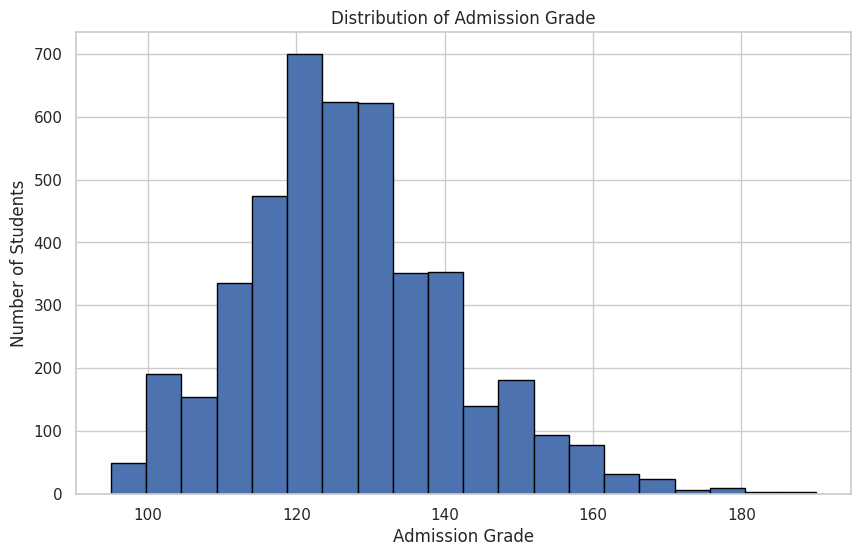

In [24]:
plt.figure(figsize=(10, 6))

plt.hist(df["Admission grade"], bins=20, edgecolor="black")

plt.title("Distribution of Admission Grade")
plt.xlabel("Admission Grade")
plt.ylabel("Number of Students")
plt.show()

### 5.2 Line Chart — Average Admission Grade by Age

A line chart is used here to show how the average admission grade changes across enrollment ages.

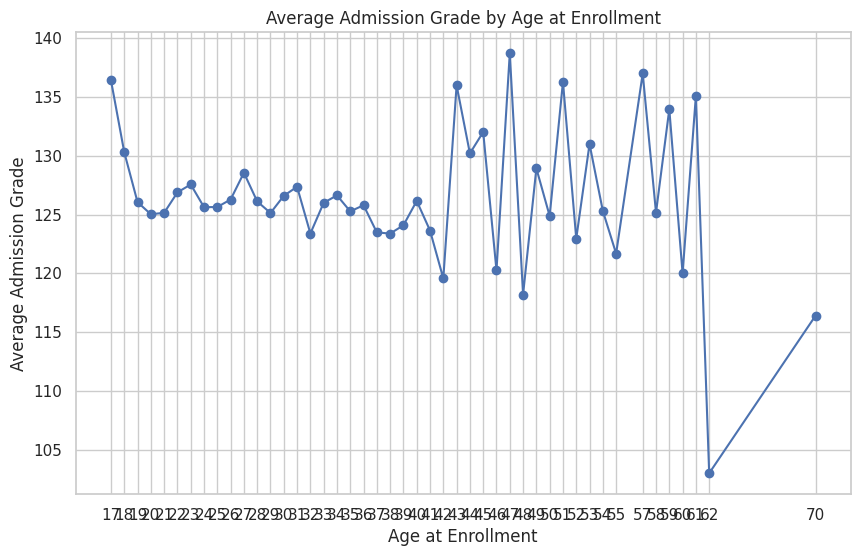

In [25]:
average_grade_by_age = (
    df.groupby("Age at enrollment")["Admission grade"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    average_grade_by_age.index,
    average_grade_by_age.values,
    marker="o"
)

plt.title("Average Admission Grade by Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Average Admission Grade")
plt.xticks(average_grade_by_age.index)
plt.show()

### 5.3 Scatter Plot — Admission Grade vs Age

A scatter plot is appropriate for examining the relationship between two numerical attributes.

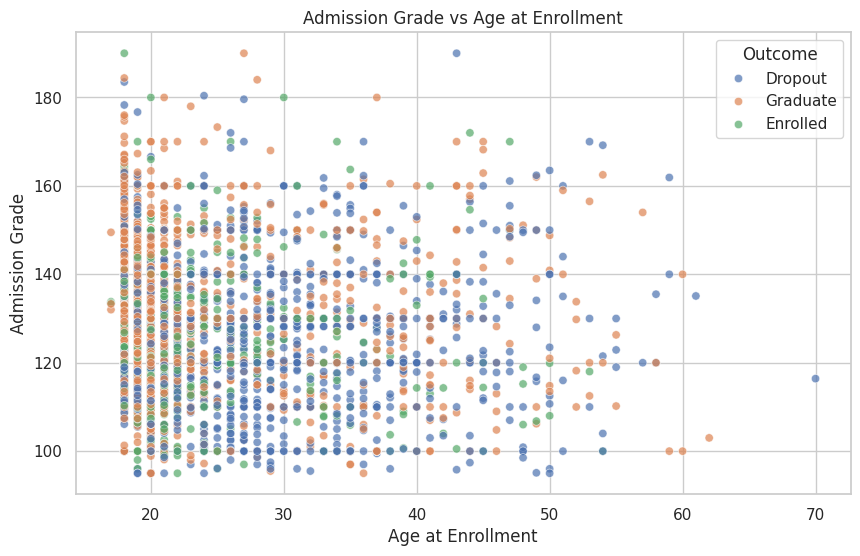

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="Admission grade",
    hue="Target",
    alpha=0.7
)

plt.title("Admission Grade vs Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Admission Grade")
plt.legend(title="Outcome")
plt.show()

### 5.4 Box Plot — Admission Grade by Student Outcome

A box plot helps compare the distribution, median and possible outliers of a numerical attribute across categories.

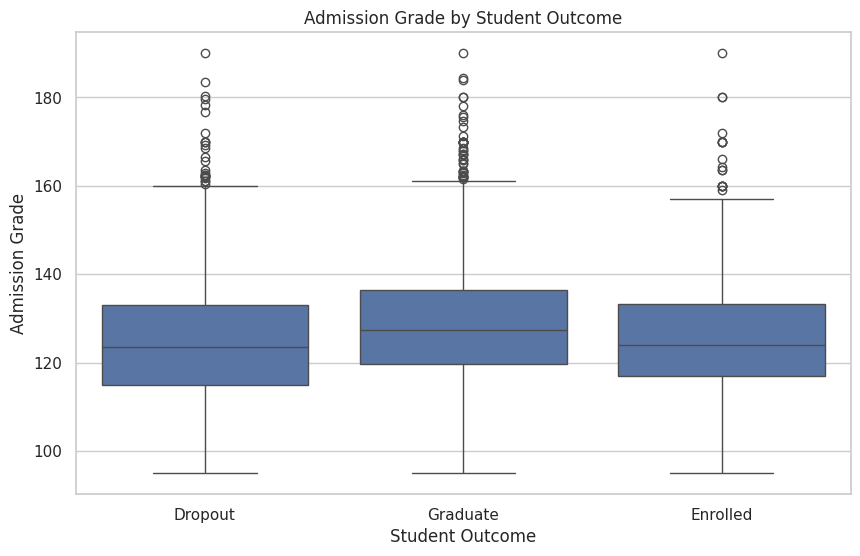

In [27]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Target",
    y="Admission grade"
)

plt.title("Admission Grade by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Admission Grade")
plt.show()

### 5.5 Pie Chart — Proportion of Student Outcomes

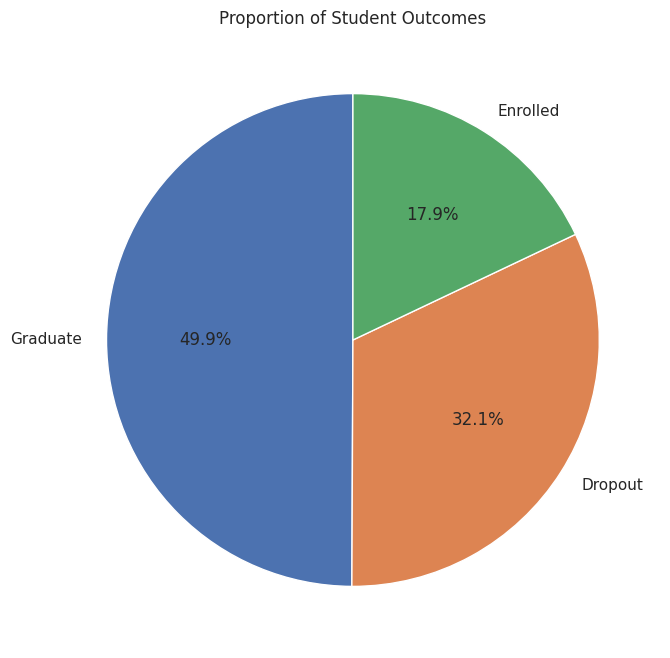

In [28]:
target_counts = df["Target"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proportion of Student Outcomes")
plt.show()

### 5.6 Bar / Count Plot — Number of Students by Outcome

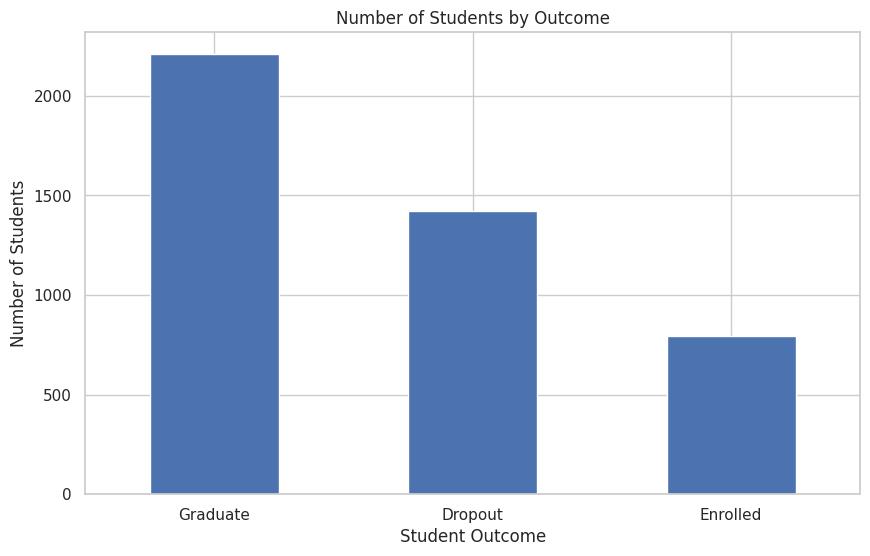

In [29]:
target_counts = df["Target"].value_counts()

plt.figure(figsize=(10, 6))

target_counts.plot(kind="bar")

plt.title("Number of Students by Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

### 5.7 Multi-Plot Grid

A multi-plot grid allows several numerical attributes to be inspected together.

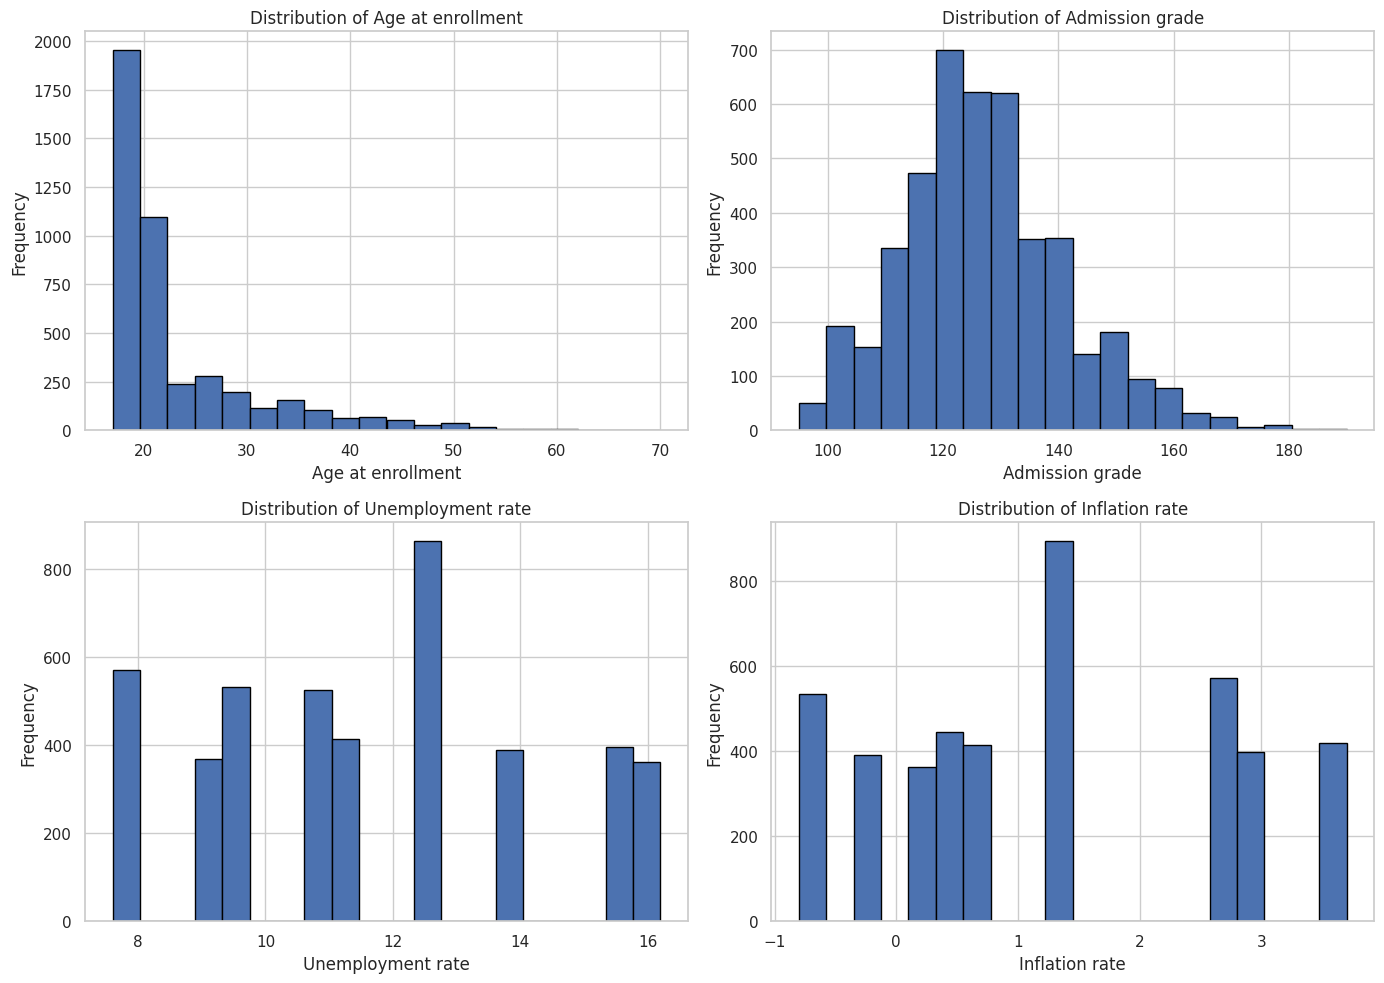

In [30]:
plot_columns = [
    "Age at enrollment",
    "Admission grade",
    "Unemployment rate",
    "Inflation rate"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, column in zip(axes.ravel(), plot_columns):
    ax.hist(df[column], bins=20, edgecolor="black")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5.8 Correlation Heatmap

A heatmap is useful for visualising correlations between numerical attributes.

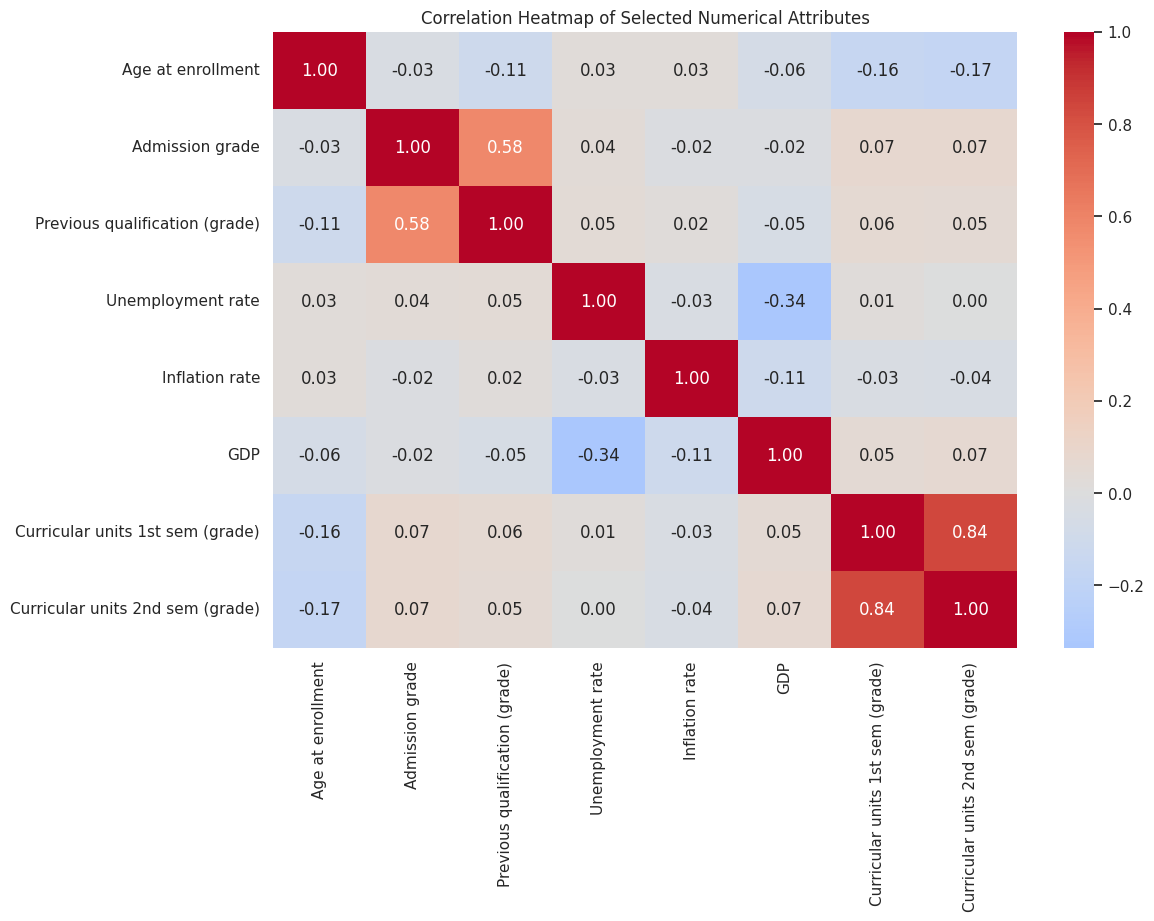

In [31]:
correlation_columns = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Selected Numerical Attributes")
plt.show()

## 6. Summary of Data Wrangling

The following operations were performed:

- Loaded the dataset correctly using a semicolon separator.
- Inspected rows, columns, shape and data types.
- Calculated descriptive statistics.
- Checked missing values and duplicate records.
- Identified numerical and categorical attributes.
- Selected columns and filtered rows using conditions.
- Used `query()` for conditional filtering.
- Examined unique values and value frequencies.
- Renamed columns.
- Dropped selected columns on a copy of the dataset.
- Replaced category labels.
- Sorted records.
- Created a derived attribute.
- Performed `groupby()` aggregation.
- Created a cross-tabulation.

## 7. Summary of Visualisation

The following graphs were created according to the type of attribute:

| Graph | Purpose |
|---|---|
| Histogram | Distribution of a numerical attribute |
| Line chart | Change in average admission grade across age |
| Scatter plot | Relationship between two numerical attributes |
| Box plot | Distribution and outliers across categories |
| Pie chart | Proportion of student outcomes |
| Count/Bar plot | Frequency of categorical outcomes |
| Multi-plot grid | Compare distributions of several numerical attributes |
| Correlation heatmap | Correlation among numerical attributes |

### Conclusion

Data wrangling makes the raw student dataset suitable for analysis by inspecting, filtering, transforming and summarising the data. Visualisation then helps identify distributions, relationships, differences between student outcomes and correlations among numerical attributes.
